# 02 — Đo thời gian trên GPU cho đúng

Mọi con số tốc độ trong dự án — 1,93×, 1,13×, "chậm hơn 8%" — đều đứng trên một phép đo
thời gian. Trên GPU laptop, phép đo đó có bốn cái bẫy: GPU chạy **bất đồng bộ**, lần chạy
đầu **chậm bất thường**, xung nhịp **dao động theo nhiệt độ**, và máy **trôi dần** trong
một phiên đo dài. Notebook này đo từng cái bẫy trên chính máy này, rồi dẫn ra sáu quy tắc
đo của dự án và định luật Amdahl — công cụ cho biết tối ưu phần nào thì đáng.

Nền tảng cần có: notebook 00 (trung vị, khoảng tin cậy, bootstrap).

| Mục | Nội dung |
|---|---|
| 1 | GPU chạy bất đồng bộ |
| 2 | Lần chạy đầu và làm nóng |
| 3 | Nhiễu: phân phối của độ trễ, trung vị và IQR, hệ số biến thiên |
| 4 | Xung nhịp và nhiệt độ |
| 5 | Trôi theo thời gian, và vì sao phải xen kẽ các cấu hình |
| 6 | Quy tắc "gấp ba lần nhiễu" |
| 7 | Profiler: thời gian nằm ở phép tính nào |
| 8 | Định luật Amdahl |

In [1]:
import json, math, statistics, sys, time
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")                      # main-branch code lives one level up
from bench.latency_probe import GpuSampler, summarize

RESULTS = Path("../results")
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (7, 3.2), "figure.dpi": 110})
dev = "cuda"

def load(name):
    return json.loads((RESULTS / name).read_text())

## 1. GPU chạy bất đồng bộ

Khi Python gọi một phép tính trên GPU, PyTorch **không chờ** GPU tính xong. Nó chỉ xếp
lệnh vào một **hàng đợi** (CUDA stream) rồi trả về ngay; GPU lấy lệnh ra chạy sau. Nhờ vậy
CPU có thể chuẩn bị lệnh tiếp theo trong lúc GPU đang bận.

Hệ quả cho việc đo: bấm giờ bằng đồng hồ của CPU quanh một lệnh GPU sẽ đo **thời gian xếp
lệnh**, không phải thời gian chạy. Ba cách đo cùng một phép nhân ma trận:

In [2]:
N = 4096
a = torch.randn(N, N, device=dev, dtype=torch.bfloat16)
b = torch.randn(N, N, device=dev, dtype=torch.bfloat16)
for _ in range(5):
    a @ b                                                # warm up (section 2)
torch.cuda.synchronize()

t = time.perf_counter(); c = a @ b
t_nosync = (time.perf_counter() - t) * 1e3               # CPU clock, no wait

torch.cuda.synchronize()
t = time.perf_counter(); c = a @ b; torch.cuda.synchronize()
t_sync = (time.perf_counter() - t) * 1e3                 # CPU clock, wait for the GPU

s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
s.record(); c = a @ b; e.record(); torch.cuda.synchronize()
t_event = s.elapsed_time(e)                              # timestamps recorded on the GPU itself

print(f"CPU clock, no synchronize : {t_nosync:7.3f} ms   <- only the time to queue the work")
print(f"CPU clock + synchronize   : {t_sync:7.3f} ms")
print(f"CUDA events               : {t_event:7.3f} ms")

CPU clock, no synchronize :   0.160 ms   <- only the time to queue the work
CPU clock + synchronize   :   6.662 ms
CUDA events               :   5.179 ms


Cách thứ nhất báo con số nhỏ hơn hàng chục lần — nó chỉ đo lúc CPU **xếp lệnh**. Hai cách
còn lại đúng:
- `torch.cuda.synchronize()` bắt CPU chờ đến khi hàng đợi trống.
- **CUDA event** là một "mốc" được chèn vào chính hàng đợi của GPU; GPU ghi thời điểm khi
  chạy tới mốc đó. Khoảng cách giữa hai mốc là thời gian GPU thực sự chạy, không lẫn độ
  trễ của CPU. Đây là cách `bench/latency_probe.py` và `bench/harness.py` dùng.

## 2. Lần chạy đầu và làm nóng

Lần đầu một phép tính chạy, hệ thống phải làm những việc chỉ làm một lần: cấp phát bộ nhớ,
nạp thư viện kernel, và để cuBLAS chọn thuật toán nhân ma trận hợp với kích thước đó. Đo
một phép nhân ma trận **kích thước mới** lần đầu và các lần sau:

In [3]:
x = torch.randn(3000, 5000, device=dev, dtype=torch.float32)     # a shape not used before
y = torch.randn(5000, 2000, device=dev, dtype=torch.float32)
times = []
for i in range(6):
    s, e = torch.cuda.Event(True), torch.cuda.Event(True)
    s.record(); x @ y; e.record(); torch.cuda.synchronize()
    times.append(s.elapsed_time(e))
print("call 1..6 (ms):", [round(t, 2) for t in times])
del a, b, c, x, y; torch.cuda.empty_cache()

call 1..6 (ms): [68.34, 11.38, 11.26, 11.29, 11.36, 11.25]


Lần đầu chậm hơn hẳn các lần sau. Vì vậy mọi phép đo trong dự án đều chạy **làm nóng**
(warm-up) vài lần trước và bỏ kết quả của chúng.

Với cả mô hình, hiệu ứng này còn rõ hơn: lần `generate` đầu tiên sau khi nạp mô hình phải
khởi tạo mọi kernel của hàng trăm lớp.

In [4]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from bench.harness import load_samples, PROMPT

MODEL = "HuggingFaceTB/SmolVLM-Instruct"
proc = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to(dev).eval()
sample = load_samples(1, seed=0)[0]
msg = [{"role": "user", "content": [{"type": "image"},
                                    {"type": "text", "text": PROMPT.format(q=sample["query"])}]}]
inputs = proc(text=proc.apply_chat_template(msg, add_generation_prompt=True),
              images=[sample["image"]], return_tensors="pt").to(dev)

def gen():
    return model.generate(**inputs, max_new_tokens=32, do_sample=False)

def timed(fn):
    s, e = torch.cuda.Event(True), torch.cuda.Event(True)
    torch.cuda.synchronize(); s.record(); fn(); e.record(); torch.cuda.synchronize()
    return s.elapsed_time(e)

with torch.no_grad():
    first = [timed(gen) for _ in range(3)]
print("first three generate calls after loading (ms):", [round(t) for t in first])

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

first three generate calls after loading (ms): [1938, 1066, 918]


## 3. Nhiễu: phân phối của độ trễ

Chạy **cùng một** câu hỏi 40 lần liên tiếp, đồng thời ghi xung nhịp và nhiệt độ GPU mỗi
0,25 giây bằng `GpuSampler` của dự án (nó gọi `nvidia-smi` trong một luồng riêng).

median 951 ms | mean 949 ms | min 896 | max 988 | p95 986
IQR = 34 ms (3.6% of median) | CV = 2.4%


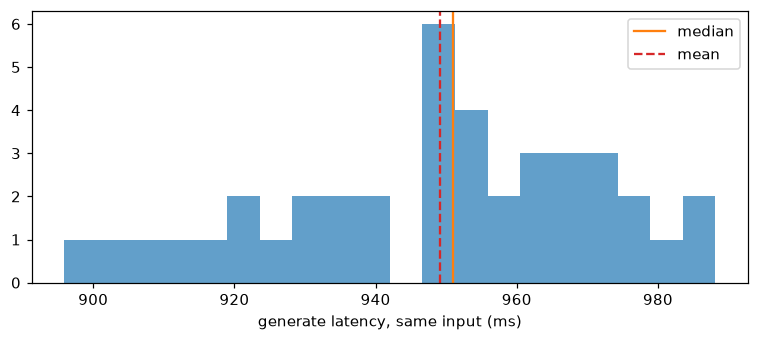

In [5]:
sampler = GpuSampler(period=0.25); sampler.start()
lat, clk_at = [], []
with torch.no_grad():
    for _ in range(40):
        lat.append(timed(gen))
        clk_at.append(sampler.rows[-1]["clock_mhz"] if sampler.rows else float("nan"))
sampler.stop()
lat = np.array(lat)
st = summarize(list(lat))
print(f"median {st['median']:.0f} ms | mean {st['mean']:.0f} ms | min {st['min']:.0f} | max {st['max']:.0f} | p95 {st['p95']:.0f}")
print(f"IQR = {st['p75'] - st['p25']:.0f} ms ({st['iqr_pct']:.1f}% of median) | CV = {st['cv_pct']:.1f}%")
plt.hist(lat, bins=20, alpha=0.7)
plt.axvline(st["median"], c="C1", label="median"); plt.axvline(st["mean"], c="C3", ls="--", label="mean")
plt.xlabel("generate latency, same input (ms)"); plt.legend(); plt.tight_layout(); plt.show()

Ba đại lượng mô tả độ phân tán dùng trong dự án:

- **Phân vị** $q$: giá trị mà $q\%$ số quan sát nằm dưới nó. Trung vị là phân vị 50; **p95**
  là phân vị 95 — "95% số lần nhanh hơn mức này", thước đo quen thuộc cho độ trễ dịch vụ.
- **Khoảng tứ phân vị** (IQR): khoảng cách giữa phân vị 75 và phân vị 25 — độ rộng của
  "nửa giữa" dữ liệu. Dự án báo IQR dưới dạng phần trăm của trung vị.
- **Hệ số biến thiên** (CV): độ lệch chuẩn chia cho trung bình, tính bằng phần trăm.

$$\mathrm{IQR} = Q_{75} - Q_{25}, \qquad \mathrm{CV} = \frac{\sigma}{\mu} \times 100\%$$

**Ký hiệu mới**
- $Q_{25}, Q_{75}$: phân vị 25 và 75 · $\sigma, \mu$: độ lệch chuẩn và trung bình của các lần đo

**Vì sao dự án báo trung vị và IQR, không báo trung bình ± độ lệch chuẩn.** Phân phối độ
trễ thường **lệch phải**: phần lớn các lần chạy dồn quanh một mức, thỉnh thoảng có lần chậm
hẳn (hệ điều hành xen vào, GPU hạ xung). Trung bình và độ lệch chuẩn bị các lần hiếm đó kéo
đi; trung vị và IQR thì gần như không. Hai đại lượng này gọi là **bền vững** (robust) với
giá trị ngoại lai. Minh hoạ: thêm một lần chạy chậm gấp năm vào 40 lần vừa đo.

In [6]:
spiked = np.append(lat, 5 * np.median(lat))
for name, v in [("40 runs", lat), ("+1 slow run", spiked)]:
    print(f"{name:<12} mean {v.mean():6.0f}  std {v.std(ddof=1):5.0f} | "
          f"median {np.median(v):6.0f}  IQR {np.percentile(v, 75) - np.percentile(v, 25):4.0f}")

40 runs      mean    949  std    23 | median    951  IQR   33
+1 slow run  mean   1042  std   595 | median    952  IQR   34


Một lần chạy bất thường làm độ lệch chuẩn tăng gấp nhiều lần, còn trung vị và IQR gần như
không đổi.

### 3.1. Nhiễu đo được từ dữ liệu thật của dự án

40 lần chạy cùng một câu cho biết nhiễu **trong vài chục giây**. Một lần chạy thật dài 25
phút có thêm nhiễu do máy nóng lên và nguội đi. Lần chạy `gate2_confirm` đo mỗi câu hỏi **hai vòng** cách nhau
hàng chục phút — tỉ số giữa hai vòng của cùng một câu chính là nhiễu của phép đo, vì câu
hỏi, cấu hình và mô hình đều giống hệt.

Nếu mỗi lần đo có sai số tương đối độc lập với độ lệch chuẩn $\sigma_r$, thì
$\log(t_2/t_1) = \log t_2 - \log t_1$ có phương sai gấp đôi (phương sai của hiệu hai biến
độc lập là tổng hai phương sai), nên

$$\sigma_r \approx \frac{\operatorname{sd}\big(\log(t_2/t_1)\big)}{\sqrt 2}$$

(Dùng logarit vì sai số của thời gian là **tương đối** — chậm 5% chứ không phải chậm 5 ms;
với sai số nhỏ, $\log(1+x) \approx x$ nên độ lệch chuẩn của log xấp xỉ CV.)

**Ký hiệu mới**
- $t_1, t_2$: thời gian của cùng một câu ở vòng 1 và vòng 2 · $\sigma_r$: nhiễu tương đối của một lần đo

In [7]:
confirm = load("gate2_confirm.json")
by = defaultdict(dict)
for r in confirm["records"]:
    if r["config"] == "baseline":
        by[r["sample_id"]][r["round_idx"]] = r["generate_ms"]
log_ratio = np.array([math.log(v[1] / v[0]) for v in by.values() if 0 in v and 1 in v])
sd_log = log_ratio.std(ddof=1)
robust = (np.percentile(log_ratio, 75) - np.percentile(log_ratio, 25)) / 1.349   # IQR -> sd for a normal
print(f"{len(log_ratio)} samples measured twice")
print(f"noise per measurement: {100 * sd_log / math.sqrt(2):.1f}% (from sd), "
      f"{100 * robust / math.sqrt(2):.1f}% (from IQR, robust to outliers)")
print(f"README's threshold used CV 8.5%, measured in gate 0 on the 256M model")

300 samples measured twice
noise per measurement: 3.2% (from sd), 3.0% (from IQR, robust to outliers)
README's threshold used CV 8.5%, measured in gate 0 on the 256M model


Con số "bền vững" dùng IQR chia 1,349 — với phân phối chuẩn, IQR bằng 1,349 lần độ lệch
chuẩn, nên phép chia này ước lượng độ lệch chuẩn mà không bị vài lần chạy bất thường kéo
lệch. Khi hai cách cho kết quả khác xa nhau, đó là dấu hiệu có **đuôi dài**: phần lớn lần đo
ổn định, vài lần lệch rất xa. Ở đây hai cách gần nhau (khoảng 3%), nên nhiễu gần với phân
phối chuẩn, không có đuôi dài đáng kể.

**Một điểm cần nói rõ:** ngưỡng nhiễu trong README (CV 8,5%, ngưỡng 25,5%) đến từ lần đo cổng
0 đầu tiên, chạy trên **mô hình 256M**, 60 lần một câu hỏi. File `gate0_latency.json` hiện tại
chứa một lần đo lại ngắn hơn (15 lần, CV 7,75%), và mô hình 2.2B chưa bao giờ được đo nhiễu
riêng theo cách của cổng 0. Hai ô ở trên chính là phép đo đó cho mô hình 2.2B, và chúng cho
kết quả nhất quán: **khoảng 2,5–3%**, thấp hơn gần ba lần con số 8,5%. Mô hình lớn hơn chạy
mỗi lần lâu hơn, nên các dao động ngắn (hệ điều hành xen vào, xung nhịp nhảy) chiếm tỉ lệ
nhỏ hơn. Hệ quả ở mục 6: ngưỡng 25,5% thận trọng hơn mức cần thiết.

## 4. Xung nhịp và nhiệt độ

GPU laptop không chạy ở một xung nhịp cố định: nó tăng xung khi mát và còn dư công suất, rồi
hạ xung khi nóng hoặc chạm giới hạn công suất. Thời gian một phép tính compute-bound tỉ lệ
nghịch với xung nhịp. Dữ liệu 40 lần chạy ở mục 3:

clock  : 1200 - 2265 MHz (median 1358)
temp   : 54 - 63 C
power  : 24.1 - 41.6 W


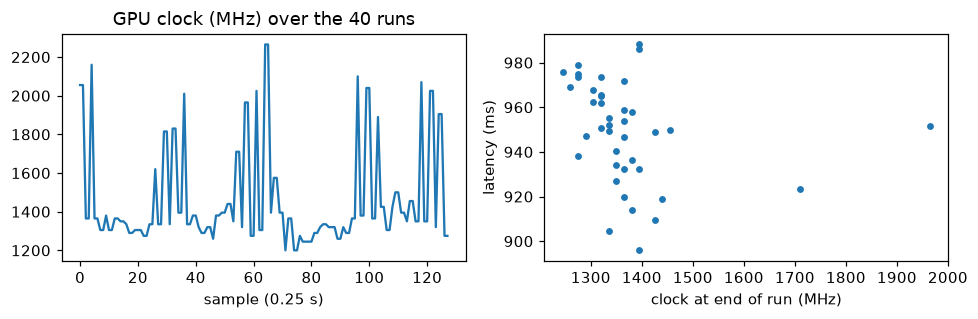

In [8]:
rows = sampler.rows
clk = np.array([r["clock_mhz"] for r in rows]); tmp = np.array([r["temp_c"] for r in rows])
pw = np.array([r["power_w"] for r in rows])
print(f"clock  : {clk.min():.0f} - {clk.max():.0f} MHz (median {np.median(clk):.0f})")
print(f"temp   : {tmp.min():.0f} - {tmp.max():.0f} C")
print(f"power  : {pw.min():.1f} - {pw.max():.1f} W")
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(clk); ax[0].set_title("GPU clock (MHz) over the 40 runs"); ax[0].set_xlabel("sample (0.25 s)")
ax[1].scatter(clk_at, lat, s=12); ax[1].set_xlabel("clock at end of run (MHz)"); ax[1].set_ylabel("latency (ms)")
plt.tight_layout(); plt.show()

Xung nhịp thay đổi đáng kể ngay trong vài chục giây. Mối liên hệ giữa xung nhịp và độ trễ
thường bị che một phần, vì `nvidia-smi` chỉ lấy mẫu mỗi 0,25 giây còn một lần chạy dài
gần một giây — con số xung nhịp ghi kèm chỉ là ảnh chụp tại một thời điểm.

Trên máy để bàn hay máy chủ, người ta **khoá xung nhịp** (`nvidia-smi --lock-gpu-clocks`) để
loại bỏ nguồn nhiễu này. GPU laptop này không cho phép, nên dự án phải **ghi lại** xung
nhịp và nhiệt độ cùng mỗi phép đo (quy tắc 6), và dùng các thiết kế đo chịu được nhiễu
(mục 5).

## 5. Trôi theo thời gian, và vì sao phải xen kẽ các cấu hình

Trong một phiên đo 25 phút, máy nóng dần lên và có thể chậm dần. Nếu đo **hết** cấu hình A
rồi mới đo cấu hình B, thì B luôn chạy trên một cái máy nóng hơn — chênh lệch do máy nóng
sẽ bị tính nhầm cho B. Mô phỏng: hai cấu hình **nhanh như nhau**, máy chậm dần tuyến tính
10% trong phiên đo.

In [9]:
n_per, drift = 100, 0.10
true_ms = 900.0
def session(order):
    """order: list of config labels in run order; returns measured latency per label."""
    out = defaultdict(list)
    for i, cfg in enumerate(order):
        slow = 1 + drift * i / (len(order) - 1)             # machine heats up over the session
        out[cfg].append(true_ms * slow * math.exp(rng.normal(0, 0.05)))
    return out

seq = session(["A"] * n_per + ["B"] * n_per)
inter = session(list(rng.permutation(["A", "B"] * n_per)))
for name, res in [("sequential A...A B...B", seq), ("interleaved, shuffled ", inter)]:
    print(f"{name}: B / A = {np.median(res['B']) / np.median(res['A']):.3f}   (truth: 1.000)")

sequential A...A B...B: B / A = 1.051   (truth: 1.000)
interleaved, shuffled : B / A = 1.006   (truth: 1.000)


Đo tuần tự báo B chậm hơn khoảng 5% — một kết luận hoàn toàn do máy nóng lên. Xen kẽ và
xáo trộn thứ tự làm trôi ảnh hưởng đều lên cả hai, nên tỉ số về gần 1.

Đây là việc `build_plan` trong `bench/harness.py` làm (quy tắc 2 và 3): mỗi **vòng** gồm mọi
cặp (câu hỏi, cấu hình), thứ tự trong vòng được xáo trộn với seed cố định. Mỗi dòng dưới đây
là (cấu hình, số thứ tự câu hỏi, vòng):

In [10]:
from bench.harness import build_plan
plan = build_plan(["baseline", "edge768"], n_samples=3, rounds=2, seed=0)
for step in plan:
    print(step)

('edge768', 1, 0)
('baseline', 2, 0)
('baseline', 1, 0)
('baseline', 0, 0)
('edge768', 2, 0)
('edge768', 0, 0)
('edge768', 1, 1)
('baseline', 0, 1)
('baseline', 1, 1)
('edge768', 2, 1)
('baseline', 2, 1)
('edge768', 0, 1)


Harness còn kiểm tra trôi trực tiếp: cấu hình đối chứng (baseline) được đo ở mọi vòng, nên so
vòng đầu với vòng cuối **trên cùng câu hỏi** cho biết máy đã trôi bao nhiêu (quy tắc 6):

In [11]:
for f in ["gate2_confirm.json", "gate2_sweep.json", "gate5_nf4_300.json", "gate6_prompt.json"]:
    print(f"{f:<20} control drift {load(f)['control_drift_pct']:+.1f}%")

gate2_confirm.json   control drift -0.4%
gate2_sweep.json     control drift -2.0%
gate5_nf4_300.json   control drift +1.1%
gate6_prompt.json    control drift +0.3%


Các lần chạy chính đều trôi dưới 2–3% — nhỏ so với các hiệu ứng được báo cáo.

## 6. Quy tắc "gấp ba lần nhiễu"

Quy tắc 5 của dự án: chỉ tuyên bố một cải thiện khi nó vượt **ba lần nhiễu đo được**. Lý do:
nếu so **một** lần đo A với **một** lần đo B, mỗi lần có nhiễu tương đối $\sigma_r$, thì hiệu
của chúng có độ lệch chuẩn $\sqrt 2\,\sigma_r$. Ngưỡng $3\sigma_r$ vì vậy nằm cách 0 khoảng
$3/\sqrt 2 \approx 2{,}1$ lần độ lệch chuẩn của hiệu — theo xấp xỉ chuẩn, xác suất nhiễu thuần
tuý vượt ngưỡng theo một chiều cụ thể chỉ khoảng 2%.

Với $\sigma_r = 8{,}5\%$ (con số của cổng 0), ngưỡng là 25,5%. Với nhiễu thật của mô hình 2.2B
đo ở mục 3.1 (khoảng 3%), ngưỡng tương ứng chỉ khoảng 9–10%. Mọi kết luận tốc độ trong README
đều vượt cả hai ngưỡng (1,93× là +93%), nên không kết luận nào bị ảnh hưởng — nhưng một cải
thiện 12% thật sự sẽ bị ngưỡng cũ gạt bỏ oan.

Đây là quy tắc **thô và thận trọng**, dành cho những phép so nhanh, ít lần đo. Với thiết kế
theo cặp trên hàng trăm câu hỏi (notebook 00), độ bất định của **trung vị tăng tốc** nhỏ hơn
nhiều: bootstrap cho 1,93× có khoảng tin cậy khoảng [1,91; 1,95]. Hai công cụ bổ sung nhau:
quy tắc 3σ chặn những kết luận vội từ vài lần chạy; thiết kế theo cặp cho con số chính xác
khi đã đầu tư đủ lần đo.

**Ký hiệu mới**
- $\sigma_r$: nhiễu tương đối của một lần đo (như ở mục 3.1)

## 7. Profiler: thời gian nằm ở phép tính nào

Đồng hồ cho biết **tổng** thời gian. Muốn biết thời gian nằm ở **phép tính nào**, dùng
**profiler**: công cụ ghi lại mọi phép tính và mọi kernel GPU cùng thời gian của chúng.
`torch.profiler` ghi được cả hai phía: thời gian CPU của từng phép toán PyTorch, và thời
gian GPU của từng kernel.

In [12]:
from torch.profiler import profile, ProfilerActivity
with torch.no_grad():
    gen()
    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        gen(); torch.cuda.synchronize()
table = prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=8, max_name_column_width=45)
print("\n".join(line[:130] for line in table.splitlines()))

USDT:2026-09-24 16:54:17 19325:19325 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:54:18 19325:19325 SyncActivityProfilerHandler.cpp:46] profiler_stop


---------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------ 
                                         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA 
---------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------ 
ampere_bf16_s1688gemm_bf16_128x128_ldg8_re...         0.00%       0.000us         0.00%       0.000us       0.000us     327.632ms 
std::enable_if<!(false), void>::type inter...         0.00%       0.000us         0.00%       0.000us       0.000us     129.613ms 
ampere_bf16_s1688gemm_bf16_128x128_ldg8_f2...         0.00%       0.000us         0.00%       0.000us       0.000us     128.258ms 
void pytorch_flash::flash_fwd_kernel<Flash...         0.00%       0.000us         0.00%       0.000us       0.000us      60.298ms 
void at::native::elementwise_kernel<128, 4...         0.00%       0.000us         0

Bảng xếp các kernel theo tổng thời gian GPU. Phần lớn thời gian là các kernel nhân ma trận
(`gemm`, `matmul`) và attention (`flash`) — đúng với những gì notebook 04 dự đoán: Transformer
dành gần hết thời gian cho các lớp tuyến tính. Notebook 05 dùng profiler để phát hiện một
điều mà đồng hồ không cho thấy: GPU **ngồi không** trong lúc chờ CPU.

Profiler cho biết thời gian theo **loại phép tính**; để biết thời gian theo **thành phần của
mô hình** (bộ mã hoá thị giác, connector, prefill, decode), dự án đo riêng từng thành phần
bằng CUDA event (`bench/breakdown.py`). Kết quả đó là đầu vào của mục cuối.

In [13]:
del model; torch.cuda.empty_cache()

## 8. Định luật Amdahl

Giả sử một phần của công việc chiếm tỉ lệ $p$ tổng thời gian, và ta làm phần đó nhanh hơn
$s$ lần. Thời gian mới (tính theo đơn vị thời gian cũ) là phần không đổi cộng phần đã tăng tốc:

$$T' = (1-p) + \frac{p}{s} \quad\Rightarrow\quad
\text{tăng tốc} = \frac{1}{(1-p) + p/s} \;\xrightarrow{\;s \to \infty\;}\; \frac{1}{1-p}$$

Kết luận của định luật: **dù phần được tối ưu nhanh vô hạn, tổng thể không bao giờ nhanh hơn
$1/(1-p)$**. Phần không tối ưu được trở thành trần.

**Ký hiệu mới**
- $p$: tỉ lệ thời gian của phần được tối ưu · $s$: mức tăng tốc của riêng phần đó

Áp vào bảng phân rã thời gian của dự án:

time shares: {'vision': '52.3%', 'connector': '0.3%', 'llm_prefill': '29.6%', 'decode': '17.5%'}

prune image tokens after encoding: only the LM prefill shrinks, p = 0.296
   ceiling 1/(1-p) = 1.42x ; keep 50% of tokens (s~2): 1.17x ; keep 25% (s~4): 1.28x
fewer tiles: vision, connector and prefill all shrink, p = 0.821
   ceiling = 5.6x ; 13 -> 5 tiles (s~2.6): 2.02x


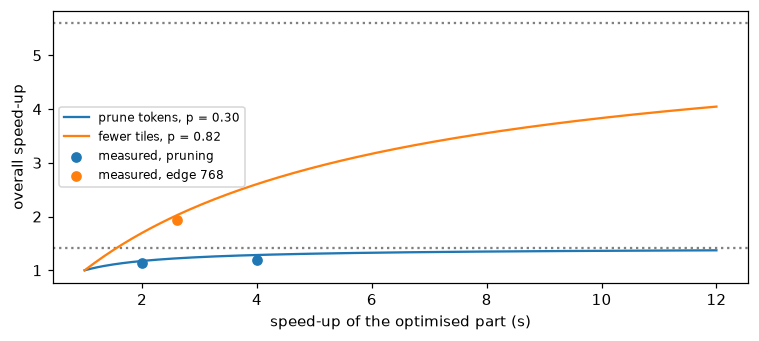

In [14]:
bd = load("breakdown.json")
share = {k: v / 100 for k, v in bd["share_pct"].items()}
print("time shares:", {k: f"{100 * v:.1f}%" for k, v in share.items()})

def amdahl(p, s):
    return 1 / ((1 - p) + p / s)

p_prefill = share["llm_prefill"]
p_img = share["vision"] + share["connector"] + share["llm_prefill"]
print(f"\nprune image tokens after encoding: only the LM prefill shrinks, p = {p_prefill:.3f}")
print(f"   ceiling 1/(1-p) = {1 / (1 - p_prefill):.2f}x ; keep 50% of tokens (s~2): {amdahl(p_prefill, 2):.2f}x "
      f"; keep 25% (s~4): {amdahl(p_prefill, 4):.2f}x")
print(f"fewer tiles: vision, connector and prefill all shrink, p = {p_img:.3f}")
print(f"   ceiling = {1 / (1 - p_img):.1f}x ; 13 -> 5 tiles (s~2.6): {amdahl(p_img, 13 / 5):.2f}x")

ss = np.linspace(1, 12, 200)
for p_, lbl in [(p_prefill, f"prune tokens, p = {p_prefill:.2f}"), (p_img, f"fewer tiles, p = {p_img:.2f}")]:
    plt.plot(ss, [amdahl(p_, s_) for s_ in ss], label=lbl)
    plt.axhline(1 / (1 - p_), ls=":", c="gray")
plt.scatter([2, 4], [1.13, 1.20], c="C0", zorder=3, label="measured, pruning")
plt.scatter([13 / 5], [1.93], c="C1", zorder=3, label="measured, edge 768")
plt.xlabel("speed-up of the optimised part (s)"); plt.ylabel("overall speed-up"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

Đọc biểu đồ:

- **Cắt token ảnh sau khi mã hoá** chỉ làm nhỏ prefill của mô hình ngôn ngữ — chưa tới một
  phần ba thời gian. Trần của nó khoảng **1,42×** dù cắt sạch mọi token. Các điểm đo thực tế
  (1,13× khi giữ 50%, 1,20× khi giữ 25%) nằm hơi thấp hơn đường lý thuyết (1,17× và 1,28×),
  vì bước chọn và gom token cũng tốn thời gian.
- **Giảm số ô ảnh** làm nhỏ cả bộ mã hoá thị giác lẫn prefill — hơn 80% thời gian. Giảm từ 13
  xuống 5 ô, lý thuyết cho khoảng 2×; đo được 1,93×.

(Ở đây giả định thời gian mỗi phần tỉ lệ thuận với số token hoặc số ô — hợp lý với các pha
compute-bound theo notebook 04. Pha decode không đổi trong cả hai trường hợp.)

Bài học tổng quát, áp dụng cho mọi bài toán tối ưu: **đo xem thời gian nằm ở đâu trước, rồi
mới chọn chỗ tối ưu.** Kỹ thuật được bàn nhiều nhất (cắt token) nhắm vào phần không đủ lớn.

## Tóm tắt: sáu quy tắc đo của dự án

| # | Quy tắc | Bẫy mà nó chặn | Mục |
|---|---|---|---|
| 1 | Vùng bấm giờ bao trọn đường đi thật, ở mọi cấu hình | so hai đường đo khác phạm vi (notebook 01, lỗi 1) | 1 |
| 2 | Các vòng là bản lặp trên cùng tập mẫu | lẫn độ khó của mẫu với nhiễu | 3.1, 5 |
| 3 | Xen kẽ và xáo trộn thứ tự cấu hình, có seed | trôi theo thời gian | 5 |
| 4 | Báo trung vị và IQR | giá trị ngoại lai | 3 |
| 5 | Chỉ tuyên bố cải thiện vượt 3 lần nhiễu | kết luận vội từ vài lần chạy | 6 |
| 6 | Ghi đại lượng bất biến và trạng thái máy | đo nhầm thứ khác (notebook 01, lỗi 4); xung nhịp | 4 |